# Movie4U: one-notebook walkthrough

Explore MovieLens, inspect the Knowledge Graph, compare KG-only and KG + GraphSAGE recommendations, and analyze the saved experiment. This notebook is read-only: it imports existing project modules and does not build data or train models implicitly.

**Setup (from `Movie4U/`):**
```sh
source .venv/bin/activate
pip install -e '.[notebook]'
python -m ipykernel install --user --name movie4u --display-name 'Python (Movie4U)'
# Only if generated data/model artifacts are missing:
python scripts/run_pipeline.py
```
Select the Movie4U kernel in VS Code or Jupyter, then Run All. Change `USER_ID` below to explore another existing user.

## 1. Setup and saved artifacts

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display

# Supports starting from Final/, Movie4U/, or Movie4U/notebooks/.
candidates = [Path.cwd(), Path.cwd() / 'Movie4U', *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / 'src/movie4u').is_dir() and (p / 'configs').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Start this notebook inside Final/ or Movie4U/.')
sys.path.insert(0, str(ROOT / 'src'))
from movie4u.recommender.inference import RecommendationService
from movie4u.recommender.evaluate import ranking_metrics

USER_ID = 1
K = 10
required = ['data/raw/movielens/ml-latest-small/ratings.csv', 'data/processed/kg/metadata.json',
            'data/processed/gnn/split_metadata.json', 'artifacts/models/gnn.pt',
            'artifacts/models/training_history.json', 'artifacts/metrics/comparison.json']
missing = [name for name in required if not (ROOT / name).is_file()]
if missing:
    raise FileNotFoundError(f'Missing {missing}. Run python scripts/run_pipeline.py from {ROOT}.')
print(f'Project: {ROOT}')
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True})

/home/sunf/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project: /home/sunf/FSB/Final/Movie4U


## 2. Understand MovieLens Small
`movieId` joins all four files; `userId` joins ratings and tags. Ratings are 0.5–5 stars. Users are anonymized; no demographics, plots, cast, or directors are included. Tags are sparse user-written phrases, not a controlled theme vocabulary.

In [2]:
raw = ROOT / 'data/raw/movielens/ml-latest-small'
tables = {name: pd.read_csv(raw / f'{name}.csv', dtype={'imdbId': str} if name == 'links' else None)
          for name in ['movies', 'ratings', 'tags', 'links']}
movies, ratings, tags = tables['movies'], tables['ratings'], tables['tags']
summary = pd.Series({
    'Users': ratings.userId.nunique(), 'Movies': len(movies), 'Ratings': len(ratings),
    'Tag applications': len(tags), 'Tagged movies': tags.movieId.nunique(),
    'Average rating': ratings.rating.mean(),
    'Interaction sparsity (%)': 100 * (1 - len(ratings) / (ratings.userId.nunique() * len(movies))),
})
display(summary.to_frame('Value'))
for name, table in tables.items():
    print(f'{name}.csv: {len(table):,} rows; columns: {list(table.columns)}')
    display(table.head(3))
print('Rating dates (UTC):', pd.to_datetime(ratings.timestamp, unit='s', utc=True).agg(['min', 'max']).to_dict())

,Value
Users,610.000000
Movies,9742.000000
Ratings,100836.000000
Tag applications,3683.000000
Tagged movies,1572.000000
Average rating,3.501557
Interaction sparsity (%),98.303173


movies.csv: 9,742 rows; columns: ['movieId', 'title', 'genres']


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


ratings.csv: 100,836 rows; columns: ['userId', 'movieId', 'rating', 'timestamp']


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224


tags.csv: 3,683 rows; columns: ['userId', 'movieId', 'tag', 'timestamp']


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992


links.csv: 9,742 rows; columns: ['movieId', 'imdbId', 'tmdbId']


,movieId,imdbId,tmdbId
0,1,0114709,862.0
1,2,0113497,8844.0
2,3,0113228,15602.0


Rating dates (UTC): {'min': Timestamp('1996-03-29 18:36:55+0000', tz='UTC'), 'max': Timestamp('2018-09-24 14:27:30+0000', tz='UTC')}


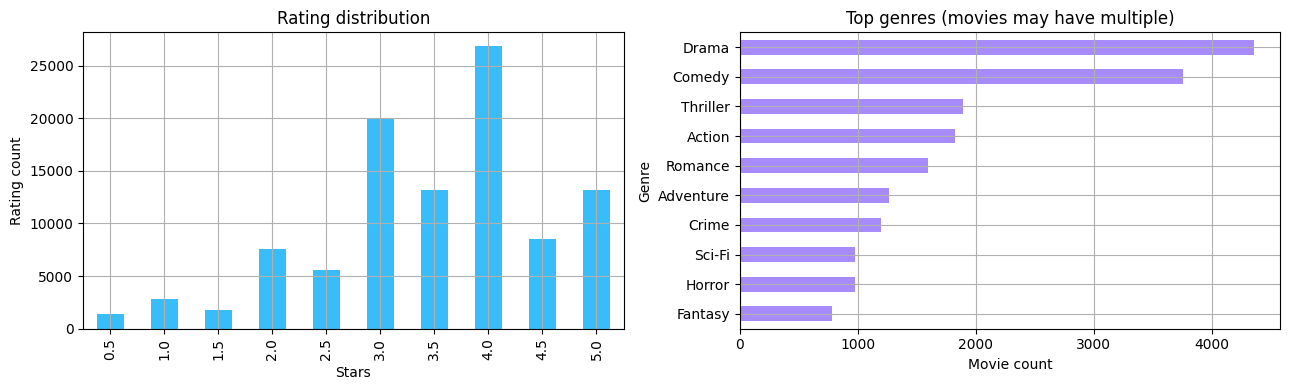

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ratings.rating.value_counts().sort_index().plot.bar(ax=axes[0], color='#38bdf8')
axes[0].set(title='Rating distribution', xlabel='Stars', ylabel='Rating count')
genre_counts = movies.genres.str.split('|').explode().value_counts().drop('(no genres listed)', errors='ignore')
genre_counts.head(10).sort_values().plot.barh(ax=axes[1], color='#a78bfa')
axes[1].set(title='Top genres (movies may have multiple)', xlabel='Movie count', ylabel='Genre')
plt.tight_layout()
plt.show()

## 3. Inspect the KG and leakage-safe training view
The canonical KG stores `User —RATED {rating, timestamp}→ Movie` and `Movie —HAS_GENRE→ Genre`. CSV node/edge tables are the graph storage; no database server is needed. Genre nodes exclude the missing-metadata marker.

For recommendation, training ratings ≥ 4 become positive interactions. Holdout ratings and their reverse edges are absent from the model graph. Both methods rank the entire catalog minus all training-rated movies. Per-user chronological splits are not a global-time simulation.

In [4]:
service = RecommendationService(ROOT)
dataset = service.dataset
if USER_ID not in dataset.user_map:
    raise ValueError(f'Unknown USER_ID {USER_ID}; select an existing MovieLens user.')
display(pd.Series(json.loads((ROOT / 'data/processed/kg/metadata.json').read_text())).to_frame('KG'))
display(pd.DataFrame([{'split': name, 'ratings': len(frame),
                       'positive_ratings': int((frame.rating >= dataset.threshold).sum()),
                       'eligible_users': len(dataset.relevant(name))}
                      for name, frame in dataset.splits.items()]))
graph = dataset.graph()
print(graph)
train_pairs = set(map(tuple, dataset.pairs(dataset.splits['train'])))
for name in ['validation', 'test']:
    assert not train_pairs.intersection(map(tuple, dataset.pairs(dataset.splits[name])))
assert np.array_equal(graph['user', 'likes', 'movie'].edge_index.numpy(), dataset.positive_train.T)
assert np.array_equal(graph['movie', 'rev_likes', 'user'].edge_index.numpy(), dataset.positive_train.T[::-1])
print('Checked: no holdout rating pairs in the training graph or its reverse edges.')

,KG
users,610
movies,9742
genres,19
ratings,100836
genre_edges,22050
source,/home/sunf/FSB/Final/Movie4U/data/raw/movielen...


,split,ratings,positive_ratings,eligible_users
0,train,81200,39517,607
1,validation,9818,4429,555
2,test,9818,4634,559


HeteroData(
  user={ num_nodes=610 },
  movie={
    num_nodes=9742,
    x=[9742, 19],
  },
  genre={ num_nodes=19 },
  (user, likes, movie)={ edge_index=[2, 39517] },
  (movie, rev_likes, user)={ edge_index=[2, 39517] },
  (movie, has_genre, genre)={ edge_index=[2, 22050] },
  (genre, rev_has_genre, movie)={ edge_index=[2, 22050] }
)
Checked: no holdout rating pairs in the training graph or its reverse edges.


## 4. User profile and both recommendation lists
KG-only uses weighted genre/path similarity plus a small training-popularity term. GraphSAGE learns signed embeddings over User/Movie/Genre nodes and scores movies with a dot-product decoder. Neither score is a calibrated probability, and raw scores are not comparable across methods.

In [5]:
history = dataset.splits['train'].query('userId == @USER_ID').merge(movies[['movieId', 'title', 'genres']], on='movieId')
print(f'User {USER_ID}: {len(history)} training ratings; {(history.rating >= dataset.threshold).sum()} positive preferences')
display(history.sort_values(['rating', 'timestamp'], ascending=False)[['movieId', 'title', 'rating', 'genres']].head(10))
recommendations = {method: service.recommend(USER_ID, method, K) for method in ['kg_only', 'kg_gnn']}
for method, rows in recommendations.items():
    print(method)
    display(pd.DataFrame([{'rank': r['rank'], 'movie_id': r['movie_id'], 'title': r['title'],
                           'genres': ', '.join(r['genres']), 'score': r['score']} for r in rows]))
overlap = {r['movie_id'] for r in recommendations['kg_only']} & {r['movie_id'] for r in recommendations['kg_gnn']}
print(f'Top-{K} overlap: {len(overlap)} movies')

User 1: 186 training ratings; 162 positive preferences


,movieId,title,rating,genres
185,2959,Fight Club (1999),5.0,Action|Crime|Drama|Thriller
184,2329,American History X (1998),5.0,Crime|Drama
182,954,Mr. Smith Goes to Washington (1939),5.0,Drama
181,2387,Very Bad Things (1998),5.0,Comedy|Crime
174,1804,"Newton Boys, The (1998)",5.0,Crime|Drama
172,2580,Go (1999),5.0,Comedy|Crime
167,1089,Reservoir Dogs (1992),5.0,Crime|Mystery|Thriller
168,1213,Goodfellas (1990),5.0,Crime|Drama
169,1617,L.A. Confidential (1997),5.0,Crime|Film-Noir|Mystery|Thriller
165,50,"Usual Suspects, The (1995)",5.0,Crime|Mystery|Thriller


kg_only


,rank,movie_id,title,genres,score
0,1,5657,Flashback (1990),"Action, Adventure, Comedy, Crime, Drama",0.818671
1,2,117646,Dragonheart 2: A New Beginning (2000),"Action, Adventure, Comedy, Drama, Fantasy, Thr...",0.818054
2,3,6990,The Great Train Robbery (1978),"Action, Adventure, Comedy, Crime, Drama",0.812357
3,4,60074,Hancock (2008),"Action, Adventure, Comedy, Crime, Fantasy",0.807488
4,5,153,Batman Forever (1995),"Action, Adventure, Comedy, Crime",0.805570
5,6,119145,Kingsman: The Secret Service (2015),"Action, Adventure, Comedy, Crime",0.804453
6,7,80219,Machete (2010),"Action, Adventure, Comedy, Crime, Thriller",0.804245
7,8,112,Rumble in the Bronx (Hont faan kui) (1995),"Action, Adventure, Comedy, Crime",0.801700
8,9,26184,"Diamond Arm, The (Brilliantovaya ruka) (1968)","Action, Adventure, Comedy, Crime, Thriller",0.800551
9,10,55116,"Hunting Party, The (2007)","Action, Adventure, Comedy, Drama, Thriller",0.797195


kg_gnn


,rank,movie_id,title,genres,score
0,1,1270,Back to the Future (1985),"Adventure, Comedy, Sci-Fi",2.815950
1,2,37857,MirrorMask (2005),"Adventure, Children, Drama, Fantasy",2.772751
2,3,150,Apollo 13 (1995),"Adventure, Drama, IMAX",2.748679
3,4,6378,"Italian Job, The (2003)","Action, Crime",2.743764
4,5,589,Terminator 2: Judgment Day (1991),"Action, Sci-Fi",2.717962
5,6,33794,Batman Begins (2005),"Action, Crime, IMAX",2.680438
6,7,8961,"Incredibles, The (2004)","Action, Adventure, Animation, Children, Comedy",2.599074
7,8,1527,"Fifth Element, The (1997)","Action, Adventure, Comedy, Sci-Fi",2.581018
8,9,353,"Crow, The (1994)","Action, Crime, Fantasy, Thriller",2.562445
9,10,318,"Shawshank Redemption, The (1994)","Crime, Drama",2.556991


Top-10 overlap: 0 movies


## 5. Visualize a recommendation's KG evidence
These paths are factual shared-genre connections from training history, not a causal explanation of the GNN prediction. A recommendation can have no shared-genre path. The drawing shows a small sample, not the entire KG.

Selected: Back to the Future (1985)


,liked_movie_id,liked_title,genre,path
0,804,She's the One (1996),Comedy,User 1 -> liked -> She's the One (1996) -> gen...
1,1210,Star Wars: Episode VI - Return of the Jedi (1983),Adventure,User 1 -> liked -> Star Wars: Episode VI - Ret...
2,1210,Star Wars: Episode VI - Return of the Jedi (1983),Sci-Fi,User 1 -> liked -> Star Wars: Episode VI - Ret...


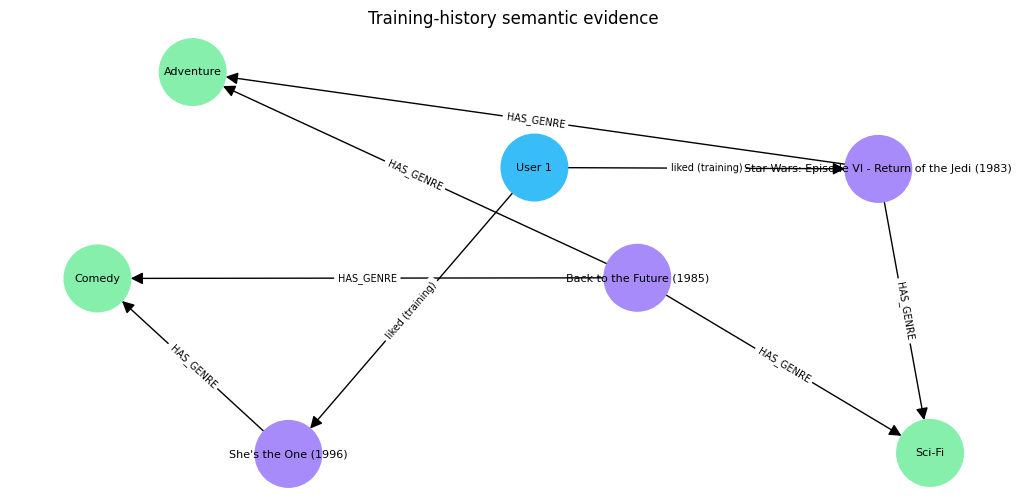

In [6]:
selected = next((r for r in recommendations['kg_gnn'] if r['evidence']), recommendations['kg_gnn'][0])
print('Selected:', selected['title'])
display(pd.DataFrame(selected['evidence']))
G = nx.DiGraph()
user_node, candidate = f'user:{USER_ID}', f"movie:{selected['movie_id']}"
G.add_node(user_node, kind='user', label=f'User {USER_ID}')
G.add_node(candidate, kind='movie', label=selected['title'])
for evidence in selected['evidence']:
    liked, genre = f"movie:{evidence['liked_movie_id']}", f"genre:{evidence['genre']}"
    G.add_node(liked, kind='movie', label=evidence['liked_title'])
    G.add_node(genre, kind='genre', label=evidence['genre'])
    G.add_edge(user_node, liked, relation='liked (training)')
    G.add_edge(liked, genre, relation='HAS_GENRE')
    G.add_edge(candidate, genre, relation='HAS_GENRE')
if not selected['evidence']:
    print('No shared-genre path found; no preference edge is invented.')
pos = nx.spring_layout(G, seed=42, k=1.8)
palette = {'user': '#38bdf8', 'movie': '#a78bfa', 'genre': '#86efac'}
fig, ax = plt.subplots(figsize=(13, 6))
nx.draw_networkx(G, pos, labels=nx.get_node_attributes(G, 'label'),
                 node_color=[palette[G.nodes[n]['kind']] for n in G],
                 node_size=2300, font_size=8, arrowsize=18, ax=ax)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, 'relation'), font_size=7, ax=ax)
ax.set_title('Training-history semantic evidence')
ax.axis('off')
plt.show()

## 6. Training history and checkpoint selection
The pipeline separates message-passing edges from supervision and samples unknown training negatives. The checkpoint is selected by validation NDCG@10, not test metrics. A falling loss alone does not guarantee better recommendations.

,epoch,loss,precision@10,recall@10,ndcg@10,hit_rate@10,coverage,evaluated_users,excluded_users_without_positive_holdout
0,1,0.745399,0.000721,0.001059,0.000843,0.007207,0.079860,555,55
1,5,0.635521,0.000541,0.000739,0.000704,0.005405,0.051940,555,55
2,10,0.558483,0.001261,0.001538,0.001396,0.012613,0.021556,555,55
3,15,0.521673,0.001081,0.002979,0.001364,0.010811,0.013139,555,55
4,20,0.497783,0.001081,0.001794,0.001144,0.010811,0.011805,555,55
5,25,0.488299,0.001982,0.003877,0.002280,0.018018,0.013652,555,55
6,30,0.471227,0.002162,0.005555,0.002705,0.021622,0.013139,555,55
7,35,0.457436,0.003784,0.008038,0.004912,0.034234,0.011805,555,55
8,40,0.440931,0.009189,0.017571,0.012085,0.079279,0.011907,555,55
9,45,0.428563,0.013514,0.024816,0.019044,0.115315,0.012626,555,55


Selected epoch: 50


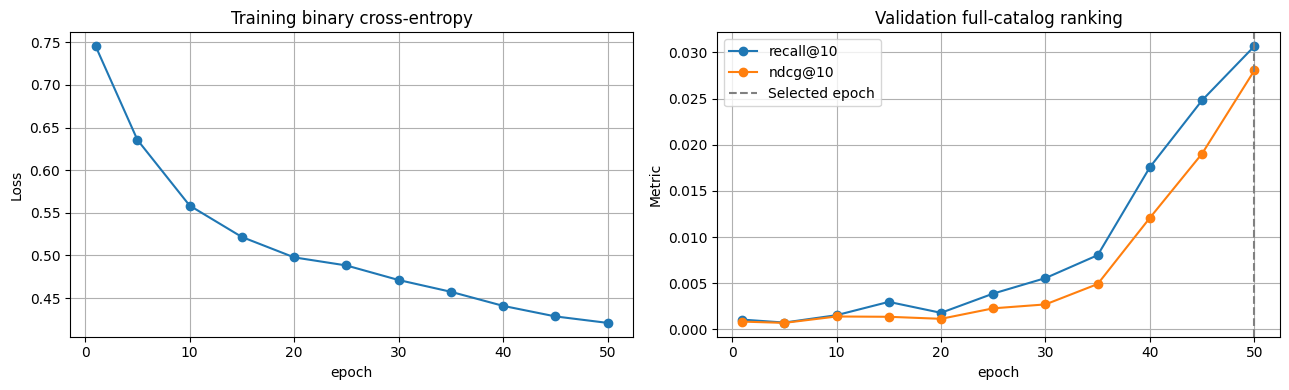

In [7]:
training = pd.read_json(ROOT / 'artifacts/models/training_history.json')
comparison = json.loads((ROOT / 'artifacts/metrics/comparison.json').read_text())
if comparison['dataset_fingerprint'] != dataset.fingerprint:
    raise ValueError('Saved evaluation does not match the current training data. Rerun the pipeline.')
display(training)
print('Selected epoch:', comparison['gnn_best_epoch'])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
training.plot(x='epoch', y='loss', ax=axes[0], legend=False, marker='o')
axes[0].set(title='Training binary cross-entropy', ylabel='Loss')
training.plot(x='epoch', y=['recall@10', 'ndcg@10'], ax=axes[1], marker='o')
axes[1].axvline(comparison['gnn_best_epoch'], color='gray', linestyle='--', label='Selected epoch')
axes[1].set(title='Validation full-catalog ranking', ylabel='Metric')
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Fair evaluation and comparison
Metrics are macro-averaged over users with positive held-out ratings; excluded users are reported. Precision@K divides hits by K, recall divides by the user's positive holdout count, and NDCG measures ranking quality. Coverage measures catalog diversity. Full-catalog evaluation is stricter than sampled binary link classification.

The next cell checks saved test metrics against current inference. It evaluates; it does not tune or retrain.

,precision@10,recall@10,ndcg@10,hit_rate@10,coverage,evaluated_users,excluded_users_without_positive_holdout
method,,,,,,,
kg_only,0.006798,0.010132,0.011959,0.060823,0.088483,559,51
kg_gnn,0.012165,0.025350,0.018920,0.107335,0.013652,559,51


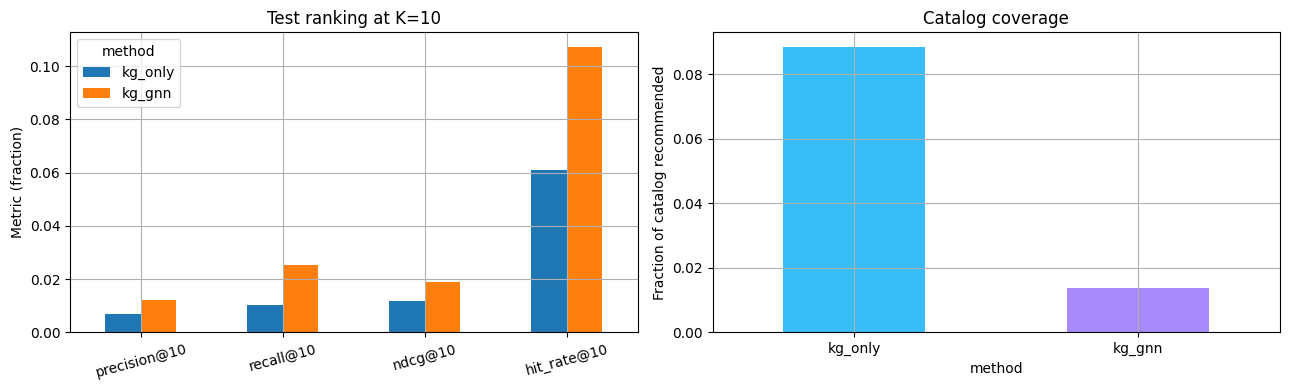

In [8]:
metric_names = [f'precision@{K}', f'recall@{K}', f'ndcg@{K}', f'hit_rate@{K}', 'coverage']
rows = []
for method, scores in service.scores.items():
    current = ranking_metrics(scores, dataset, 'test', K)
    if K == 10:
        saved = comparison['models'][method]['test']
        for key in metric_names:
            assert np.isclose(current[key], saved[key], rtol=1e-5, atol=1e-8), f'Metric mismatch: {method}/{key}'
    rows.append({'method': method, **current})
results = pd.DataFrame(rows).set_index('method')
display(results)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
results[metric_names[:-1]].T.plot.bar(ax=axes[0], rot=15)
axes[0].set(title=f'Test ranking at K={K}', ylabel='Metric (fraction)')
results['coverage'].plot.bar(ax=axes[1], color=['#38bdf8', '#a78bfa'], rot=0)
axes[1].set(title='Catalog coverage', ylabel='Fraction of catalog recommended')
plt.tight_layout()
plt.show()

## 8. Conclusions, limitations, and next steps

- Interpret the measured table, not an assumption that GNNs always win. Inspect both ranking quality and coverage.
- This is a single-seed MVP, not SOTA evidence. Add stronger baselines, multiple seeds, uncertainty estimates, and validation-only tuning before research claims.
- Unobserved interactions are unknown; held-out positives are incomplete ground truth.
- User cold start, live feedback/retraining, and true inductive item inference are not implemented.
- External metadata and a conversational agent remain optional extensions.
- Run the backend and mobile app using the instructions in `README.md` and `mobile/README.md`.

**References:** Alessandro Negro, *Knowledge Graphs and LLMs in Action*, chapter 12, §12.2 (printed pp. 317–334); project protocol in `docs/evaluation.md`; KG schema in `docs/kg-schema.md`. MovieLens attribution and usage conditions are in the source dataset's `README.txt`.